
# 영화 코퍼스 기반 워드 임베딩 편향성(WEAT) 분석

## 프로젝트 목표

주어진 영화 코퍼스를 바탕으로 다음 평가 항목을 충족한다.

1. 영화 코퍼스로 Word2Vec 워드 임베딩 모델을 구축한다.
2. `most_similar()` 결과를 확인하여 의미적으로 타당한지 검증한다.
3. 영화 장르별 target 단어와 예술영화/일반영화 attribute 단어 집합을 생성한다.
4. 중복 단어를 제거하여 각 개념축을 대표하는 단어 집합을 구성한다.
5. WEAT score를 계산하고 시각화한다.
6. 장르별 예술영화/일반영화 편향성을 해석한다.

> **Colab 제출용 노트북**
>
> 데이터 다운로드 → 전처리 → Word2Vec → most_similar → TF-IDF 단어셋 → WEAT → 시각화까지 한 번에 재현할 수 있도록 구성하였다.


## 1. Colab 환경 준비

In [ ]:

# Colab에서 최초 1회 실행
!apt-get -qq update
!apt-get -qq install -y openjdk-17-jdk fonts-nanum
!pip -q install gdown konlpy gensim scikit-learn matplotlib seaborn numpy pandas


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package libatspi2.0-0:amd64.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../00-libatspi2.0-0_2.44.0-3_amd64.deb ...
Unpacking libatspi2.0-0:amd64 (2.44.0-3) ...
Selecting previously unselected package libxtst6:amd64.
Preparing to unpack .../01-libxtst6_2%3a1.2.3-1build4_amd64.deb ...
Unpacking libxtst6:amd64 (2:1.2.3-1build4) ...
Selecting previously unselected package session-migration.
Preparing to unpack .../02-session-migration_0.3.6_amd64.deb ...
Unpacking session-migration (0.3.6) ...
Selecting previously unselected package gsettings-desktop-schemas.
Preparing to unpack .../03-gsettings-desktop-schemas_42.0-1ubuntu1_all.deb ...
Unpacking gsettings-desktop-schemas (42.0-1ubuntu1) ...
Selecting previously unselected

In [ ]:

import os
import re
import itertools
import zipfile
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import Word2Vec

# Java / 한글 폰트 설정
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"

plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

print("환경 준비 완료")


환경 준비 완료


In [ ]:
import matplotlib.font_manager as fm
import shutil
import os

# Matplotlib cache directory in Colab is typically /root/.cache/matplotlib
cache_dir = os.path.join(os.path.expanduser('~'), '.cache', 'matplotlib')
print(f"Matplotlib font cache directory: {cache_dir}")

# Remove existing font cache files
if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)
    print("Font cache cleared.")

# Ensure the cache directory exists before matplotlib tries to write to it
os.makedirs(cache_dir, exist_ok=True)

# Rebuild font cache
fm._load_fontmanager(try_read_cache=False)
print("Font cache rebuilt.")

Matplotlib font cache directory: /root/.cache/matplotlib


Font cache rebuilt.


## 2. 영화 코퍼스 다운로드 및 압축 해제

Google Drive의 코퍼스를 Colab의 `/content/w2v`에 저장한다. 루트(`/`)가 아닌 `/content`를 사용하여 읽기 전용 파일 시스템 오류를 피한다.

In [ ]:

import gdown

BASE_DIR = "/content/w2v"
ZIP_PATH = os.path.join(BASE_DIR, "synopsis.zip")
DATA_DIR = os.path.join(BASE_DIR, "synopsis")

os.makedirs(BASE_DIR, exist_ok=True)

FILE_ID = "19NmxfaX7tJn6dAGvq-EM1wfw63momOq0"

gdown.download(
    id=FILE_ID,
    output=ZIP_PATH,
    quiet=False
)

print("압축 파일:", ZIP_PATH)
print("존재 여부:", os.path.exists(ZIP_PATH))


Downloading...
From: https://drive.google.com/uc?id=19NmxfaX7tJn6dAGvq-EM1wfw63momOq0
To: /content/w2v/synopsis.zip
100%|██████████| 18.4M/18.4M [00:00<00:00, 23.0MB/s]

압축 파일: /content/w2v/synopsis.zip
존재 여부: True


In [ ]:

# 압축 해제
if os.path.isdir(DATA_DIR):
    shutil.rmtree(DATA_DIR)

os.makedirs(DATA_DIR, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(DATA_DIR)

print("압축 해제 완료")
print("상위 파일/폴더:")
for name in os.listdir(DATA_DIR)[:30]:
    print(" -", name)


압축 해제 완료
상위 파일/폴더:
 - synopsis_documentary.txt
 - synopsis_show.txt
 - synopsis_thriller.txt
 - synopsis_comedy.txt
 - synopsis_war.txt
 - synopsis_action.txt
 - synopsis_animation.txt
 - synopsis_horror.txt
 - synopsis_family.txt
 - synopsis.txt
 - synopsis_western.txt
 - synopsis_mystery.txt
 - synopsis_musical.txt
 - synopsis_adventure.txt
 - synopsis_art.txt
 - synopsis_historical.txt
 - synopsis_romance.txt
 - synopsis_SF.txt
 - synopsis_fantasy.txt
 - synopsis_adult.txt
 - synopsis_etc.txt
 - synopsis_gen.txt
 - synopsis_crime.txt
 - synopsis_drama.txt


## 3. 데이터 구조 확인

코퍼스 파일이 실제로 존재하는지 먼저 확인한다.

In [ ]:

for root, dirs, files in os.walk(DATA_DIR):
    print(f"\n[DIR] {root}")
    for f in files[:20]:
        print("  ", f)



[DIR] /content/w2v/synopsis
   synopsis_documentary.txt
   synopsis_show.txt
   synopsis_thriller.txt
   synopsis_comedy.txt
   synopsis_war.txt
   synopsis_action.txt
   synopsis_animation.txt
   synopsis_horror.txt
   synopsis_family.txt
   synopsis.txt
   synopsis_western.txt
   synopsis_mystery.txt
   synopsis_musical.txt
   synopsis_adventure.txt
   synopsis_art.txt
   synopsis_historical.txt
   synopsis_romance.txt
   synopsis_SF.txt
   synopsis_fantasy.txt
   synopsis_adult.txt


## 4. 분석 설정

In [ ]:

GENRE_FILES = {
    "SF": "synopsis_SF.txt",
    "가족": "synopsis_가족.txt",
    "공포": "synopsis_공포(스릴러).txt",
    "다큐멘터리": "synopsis_다큐멘터리.txt",
    "드라마": "synopsis_드라마.txt",
    "멜로로맨스": "synopsis_멜로로맨스.txt",
    "미스터리": "synopsis_미스터리.txt",
    "범죄": "synopsis_범죄.txt",
    "애니메이션": "synopsis_애니메이션.txt",
    "액션": "synopsis_액션.txt",
    "코미디": "synopsis_코미디.txt",
    "판타지": "synopsis_판타지.txt",
}

ART_FILE = "synopsis_art.txt"
GENERAL_FILE = "synopsis_gen.txt"

N_TARGET_WORDS = 15
N_ATTRIBUTE_WORDS = 15
MIN_TOKEN_LEN = 2

print("데이터 경로:", DATA_DIR)
print("장르 수:", len(GENRE_FILES))


데이터 경로: /content/w2v/synopsis
장르 수: 12


## 5. 데이터 로드 및 형태소 분석

In [ ]:
import os

print("DATA_DIR =", DATA_DIR)

for root, dirs, files in os.walk(DATA_DIR):
    for f in files:
        print(os.path.join(root, f))

DATA_DIR = /content/w2v/synopsis
/content/w2v/synopsis/synopsis_documentary.txt
/content/w2v/synopsis/synopsis_show.txt
/content/w2v/synopsis/synopsis_thriller.txt
/content/w2v/synopsis/synopsis_comedy.txt
/content/w2v/synopsis/synopsis_war.txt
/content/w2v/synopsis/synopsis_action.txt
/content/w2v/synopsis/synopsis_animation.txt
/content/w2v/synopsis/synopsis_horror.txt
/content/w2v/synopsis/synopsis_family.txt
/content/w2v/synopsis/synopsis.txt
/content/w2v/synopsis/synopsis_western.txt
/content/w2v/synopsis/synopsis_mystery.txt
/content/w2v/synopsis/synopsis_musical.txt
/content/w2v/synopsis/synopsis_adventure.txt
/content/w2v/synopsis/synopsis_art.txt
/content/w2v/synopsis/synopsis_historical.txt
/content/w2v/synopsis/synopsis_romance.txt
/content/w2v/synopsis/synopsis_SF.txt
/content/w2v/synopsis/synopsis_fantasy.txt
/content/w2v/synopsis/synopsis_adult.txt
/content/w2v/synopsis/synopsis_etc.txt
/content/w2v/synopsis/synopsis_gen.txt
/content/w2v/synopsis/synopsis_crime.txt
/conte

In [ ]:

from konlpy.tag import Okt

tokenizer = Okt()
print("형태소 분석기: Okt")

def load_lines(filepath):
    path = os.path.join(DATA_DIR, filepath)
    if not os.path.exists(path):
        print(f"[경고] 파일 없음: {path}")
        return []
    with open(path, encoding="utf-8") as f:
        return [line.strip() for line in f if line.strip()]

def clean_text(text):
    text = re.sub(r"[^가-힣a-zA-Z0-9\s]", " ", text)
    return re.sub(r"\s+", " ", text).strip()

def tokenize_nouns(text):
    nouns = tokenizer.nouns(text)
    return [w for w in nouns if len(w) >= MIN_TOKEN_LEN]

def build_corpus():
    print("코퍼스 로딩 및 형태소 분석 중...")

    genre_raw = {g: load_lines(f) for g, f in GENRE_FILES.items()}
    art_raw = load_lines(ART_FILE)
    gen_raw = load_lines(GENERAL_FILE)

    genre_tokens = {
        g: [tokenize_nouns(clean_text(line)) for line in lines]
        for g, lines in genre_raw.items()
    }
    art_tokens = [tokenize_nouns(clean_text(line)) for line in art_raw]
    gen_tokens = [tokenize_nouns(clean_text(line)) for line in gen_raw]

    return genre_tokens, art_tokens, gen_tokens

genre_tokens, art_tokens, gen_tokens = build_corpus()

print("장르별 문서 수")
for g, docs in genre_tokens.items():
    print(f"{g:8s}: {len(docs)}")

print("예술영화:", len(art_tokens))
print("일반영화:", len(gen_tokens))


형태소 분석기: Okt
코퍼스 로딩 및 형태소 분석 중...
[경고] 파일 없음: /content/w2v/synopsis/synopsis_가족.txt
[경고] 파일 없음: /content/w2v/synopsis/synopsis_공포(스릴러).txt
[경고] 파일 없음: /content/w2v/synopsis/synopsis_다큐멘터리.txt
[경고] 파일 없음: /content/w2v/synopsis/synopsis_드라마.txt
[경고] 파일 없음: /content/w2v/synopsis/synopsis_멜로로맨스.txt
[경고] 파일 없음: /content/w2v/synopsis/synopsis_미스터리.txt
[경고] 파일 없음: /content/w2v/synopsis/synopsis_범죄.txt
[경고] 파일 없음: /content/w2v/synopsis/synopsis_애니메이션.txt
[경고] 파일 없음: /content/w2v/synopsis/synopsis_액션.txt
[경고] 파일 없음: /content/w2v/synopsis/synopsis_코미디.txt
[경고] 파일 없음: /content/w2v/synopsis/synopsis_판타지.txt
장르별 문서 수
SF      : 1023
가족      : 0
공포      : 0
다큐멘터리   : 0
드라마     : 0
멜로로맨스   : 0
미스터리    : 0
범죄      : 0
애니메이션   : 0
액션      : 0
코미디     : 0
판타지     : 0
예술영화: 14435
일반영화: 48116


## 6. Word2Vec 워드 임베딩 모델 구축

In [ ]:

all_sentences = []

for toks in genre_tokens.values():
    all_sentences.extend(toks)

all_sentences.extend(art_tokens)
all_sentences.extend(gen_tokens)

all_sentences = [s for s in all_sentences if len(s) > 0]

print("학습 문장 수:", len(all_sentences))

w2v_model = Word2Vec(
    sentences=all_sentences,
    vector_size=100,
    window=5,
    min_count=5,
    sg=1,
    workers=4,
    epochs=10,
    seed=42
)

print("Word2Vec 모델 학습 완료!")
print("Vocabulary size:", len(w2v_model.wv))


학습 문장 수: 62908
Word2Vec 모델 학습 완료!
Vocabulary size: 16782


## 7. `most_similar()` 의미적 검증

아래 결과를 보고 영화 코퍼스의 문맥상 연관성이 높은 단어가 나오는지 확인한다.

In [ ]:

def sanity_check(model, query_words=("영화", "사랑", "액션"), topn=10):
    results = {}
    for w in query_words:
        if w in model.wv:
            sims = model.wv.most_similar(w, topn=topn)
            results[w] = sims
            print(f"\n[most_similar] '{w}'")
            for word, score in sims:
                print(f"  {word:12s} {score:.3f}")
        else:
            print(f"[안내] '{w}'는 vocabulary에 없습니다.")
    return results

similarity_results = sanity_check(w2v_model)



[most_similar] '영화'
  뒷이야기         0.708
  무성영화         0.698
  사극           0.691
  픽션           0.683
  키아로스타미       0.683
  시대극          0.682
  플롯           0.675
  차이밍량         0.673
  극영화          0.672
  페이크          0.672

[most_similar] '사랑'
  로미오          0.654
  해피엔딩         0.654
  종이학          0.651
  파란만장         0.636
  적령           0.632
  토노           0.630
  슈코           0.628
  아스트레         0.627
  짊어지          0.627
  아슬아슬         0.625

[most_similar] '액션'
  하드코어         0.756
  블록버스터        0.742
  코믹           0.738
  매트릭스         0.737
  무협           0.733
  어드벤처         0.728
  대작           0.720
  고어           0.720
  짜임새          0.716
  호러           0.712


## 8. Target / Attribute 단어 집합 생성

TF-IDF 상위 단어를 후보로 사용하고, Word2Vec vocabulary에 존재하는 단어만 남긴다. 예술/일반 attribute 사이의 중복을 먼저 제거한 뒤, 장르 target에서도 attribute와 겹치는 단어를 제거한다.

In [ ]:

def get_tfidf_top_words(model, doc_list_of_token_lists, top_n=15, exclude=None):
    exclude = exclude or set()
    docs = [" ".join(toks) for toks in doc_list_of_token_lists if toks]

    if not docs:
        return []

    vectorizer = TfidfVectorizer()
    tfidf = vectorizer.fit_transform(docs)

    scores = np.asarray(tfidf.sum(axis=0)).flatten()
    vocab = vectorizer.get_feature_names_out()

    ranked = sorted(
        zip(vocab, scores),
        key=lambda x: -x[1]
    )

    result = []

    for word, _ in ranked:
        if word in exclude:
            continue
        if word not in model.wv:
            continue

        result.append(word)

        if len(result) >= top_n:
            break

    return result


art_raw = get_tfidf_top_words(
    w2v_model,
    art_tokens,
    top_n=N_ATTRIBUTE_WORDS * 2
)

gen_raw = get_tfidf_top_words(
    w2v_model,
    gen_tokens,
    top_n=N_ATTRIBUTE_WORDS * 2
)

# 예술/일반 attribute 간 중복 제거
overlap = set(art_raw) & set(gen_raw)

attr_art = [
    w for w in art_raw
    if w not in overlap
][:N_ATTRIBUTE_WORDS]

attr_general = [
    w for w in gen_raw
    if w not in overlap
][:N_ATTRIBUTE_WORDS]

# target은 attribute 단어와 겹치지 않도록 제거
attr_all = set(attr_art) | set(attr_general)

genre_targets = {}

for genre, toks in genre_tokens.items():
    words = get_tfidf_top_words(
        w2v_model,
        toks,
        top_n=N_TARGET_WORDS * 2,
        exclude=attr_all
    )
    genre_targets[genre] = words[:N_TARGET_WORDS]

print("예술영화 attribute")
print(attr_art)

print("\n일반영화 attribute")
print(attr_general)

print("\n장르별 target")
for genre, words in genre_targets.items():
    print(f"[{genre}] {words}")


예술영화 attribute
['세상', '과연', '마을', '다시', '서로', '마음', '소녀', '우리', '인생', '아들', '다른']

일반영화 attribute
['국제', '서울', '단편', '애니메이션', '다큐', '남편', '독립', '부산', '인디애니페스트', '부천', '대한']

장르별 target
[SF] ['시작', '위해', '지구', '인류', '자신', '인간', '사람', '미래', '모든', '세계', '시간', '우주', '그녀', '존재', '로봇']
[가족] []
[공포] []
[다큐멘터리] []
[드라마] []
[멜로로맨스] []
[미스터리] []
[범죄] []
[애니메이션] []
[액션] []
[코미디] []
[판타지] []


## 9. 단어 집합 중복 및 크기 검증

In [ ]:

print("예술 attribute 수:", len(attr_art))
print("일반 attribute 수:", len(attr_general))

print(
    "예술/일반 attribute 중복:",
    set(attr_art) & set(attr_general)
)

for genre, words in genre_targets.items():
    duplicates = set(words) & attr_all
    print(
        f"{genre:8s} | target={len(words):2d} | "
        f"attribute와 중복={len(duplicates)}"
    )


예술 attribute 수: 11
일반 attribute 수: 11
예술/일반 attribute 중복: set()
SF       | target=15 | attribute와 중복=0
가족       | target= 0 | attribute와 중복=0
공포       | target= 0 | attribute와 중복=0
다큐멘터리    | target= 0 | attribute와 중복=0
드라마      | target= 0 | attribute와 중복=0
멜로로맨스    | target= 0 | attribute와 중복=0
미스터리     | target= 0 | attribute와 중복=0
범죄       | target= 0 | attribute와 중복=0
애니메이션    | target= 0 | attribute와 중복=0
액션       | target= 0 | attribute와 중복=0
코미디      | target= 0 | attribute와 중복=0
판타지      | target= 0 | attribute와 중복=0


## 10. WEAT 계산

In [ ]:

def cos_sim(a, b):
    denominator = np.linalg.norm(a) * np.linalg.norm(b)
    if denominator == 0:
        return np.nan
    return np.dot(a, b) / denominator

def association(word, A, B, model):
    wv = model.wv[word]

    sims_a = [
        cos_sim(wv, model.wv[a])
        for a in A
        if a in model.wv
    ]

    sims_b = [
        cos_sim(wv, model.wv[b])
        for b in B
        if b in model.wv
    ]

    sims_a = [x for x in sims_a if not np.isnan(x)]
    sims_b = [x for x in sims_b if not np.isnan(x)]

    if not sims_a or not sims_b:
        return np.nan

    return np.mean(sims_a) - np.mean(sims_b)

def weat_effect_size(X, Y, A, B, model):
    X = [w for w in X if w in model.wv]
    Y = [w for w in Y if w in model.wv]

    if not X or not Y:
        return np.nan

    sx = np.array([
        association(w, A, B, model)
        for w in X
    ])

    sy = np.array([
        association(w, A, B, model)
        for w in Y
    ])

    sx = sx[~np.isnan(sx)]
    sy = sy[~np.isnan(sy)]

    if len(sx) == 0 or len(sy) == 0:
        return np.nan

    mean_diff = sx.mean() - sy.mean()
    pooled_std = np.concatenate([sx, sy]).std()

    if pooled_std == 0:
        return np.nan

    return mean_diff / pooled_std

def compute_weat_matrix(
    genre_targets,
    attr_art,
    attr_general,
    model
):
    genres = list(genre_targets.keys())
    matrix = pd.DataFrame(
        index=genres,
        columns=genres,
        dtype=float
    )

    for g1, g2 in itertools.product(genres, genres):
        if g1 == g2:
            matrix.loc[g1, g2] = 0.0
            continue

        matrix.loc[g1, g2] = weat_effect_size(
            genre_targets[g1],
            genre_targets[g2],
            attr_art,
            attr_general,
            model
        )

    return matrix

def compute_single_axis_bias(
    genre_targets,
    attr_art,
    attr_general,
    model
):
    scores = {}

    for genre, words in genre_targets.items():
        vals = [
            association(
                w,
                attr_art,
                attr_general,
                model
            )
            for w in words
            if w in model.wv
        ]

        vals = [
            v for v in vals
            if not np.isnan(v)
        ]

        scores[genre] = np.mean(vals) if vals else np.nan

    return scores

weat_matrix = compute_weat_matrix(
    genre_targets,
    attr_art,
    attr_general,
    w2v_model
)

single_scores = compute_single_axis_bias(
    genre_targets,
    attr_art,
    attr_general,
    w2v_model
)

print("WEAT matrix")
display(weat_matrix.round(3))

print("\n장르별 예술/일반 편향 점수")
display(
    pd.Series(single_scores, name="WEAT")
    .sort_values()
    .round(3)
)


WEAT matrix


,SF,가족,공포,다큐멘터리,드라마,멜로로맨스,미스터리,범죄,애니메이션,액션,코미디,판타지
SF,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
가족,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
공포,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
다큐멘터리,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
드라마,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
멜로로맨스,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN
미스터리,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN
범죄,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN
애니메이션,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
액션,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN



장르별 예술/일반 편향 점수


,WEAT
SF,0.008
가족,NaN
공포,NaN
다큐멘터리,NaN
드라마,NaN
멜로로맨스,NaN
미스터리,NaN
범죄,NaN
애니메이션,NaN
액션,NaN


## 11. WEAT 시각화 ① 장르 간 WEAT Heatmap

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51313 (\N{HANGUL SYLLABLE JOG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 44277 (\N{HANGUL SYLLABLE GONG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 45796 (\N{HANGUL SYLLABLE DA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 53328 (\N{HANGUL SYLLABLE KYU}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/l

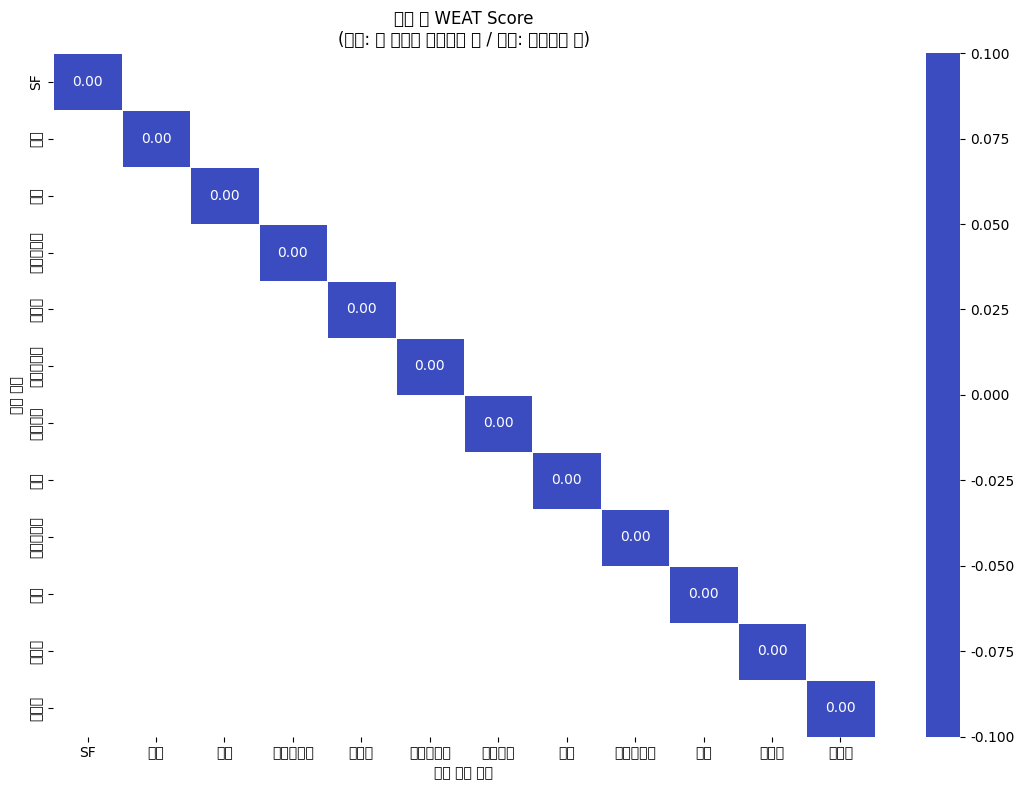

저장: /content/weat_heatmap.png


In [ ]:

heatmap_path = "/content/weat_heatmap.png"

plt.figure(figsize=(11, 8))

sns.heatmap(
    weat_matrix.astype(float),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title(
    "장르 간 WEAT Score\n"
    "(양수: 행 장르가 예술영화 쪽 / 음수: 일반영화 쪽)"
)
plt.xlabel("비교 대상 장르")
plt.ylabel("기준 장르")
plt.tight_layout()

plt.savefig(
    heatmap_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("저장:", heatmap_path)


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51313 (\N{HANGUL SYLLABLE JOG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 44277 (\N{HANGUL SYLLABLE GONG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 45796 (\N{HANGUL SYLLABLE DA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 53328 (\N{HANGUL SYLLABLE KYU}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/l

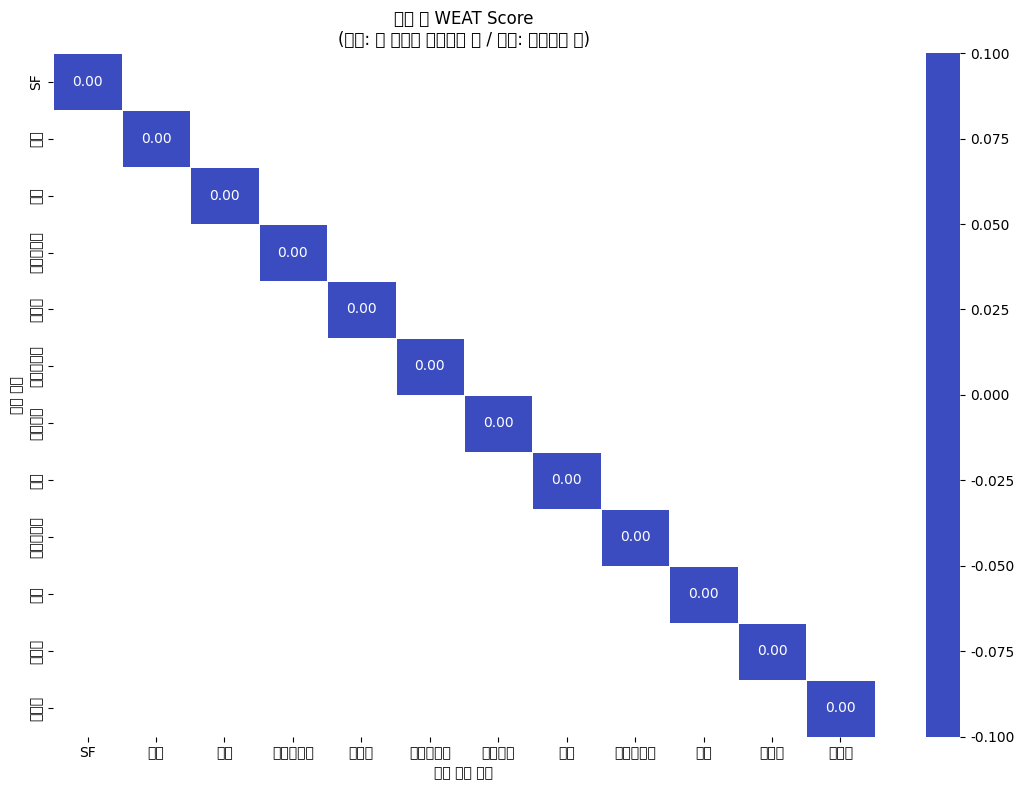

저장: /content/weat_heatmap.png


In [ ]:
heatmap_path = "/content/weat_heatmap.png"

plt.figure(figsize=(11, 8))

sns.heatmap(
    weat_matrix.astype(float),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title(
    "장르 간 WEAT Score\n"
    "(양수: 행 장르가 예술영화 쪽 / 음수: 일반영화 쪽)"
)
plt.xlabel("비교 대상 장르")
plt.ylabel("기준 장르")
plt.tight_layout()

plt.savefig(
    heatmap_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("저장:", heatmap_path)

/tmp/ipykernel_2843/657036301.py:43: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2843/657036301.py:43: UserWarning: Glyph 49696 (\N{HANGUL SYLLABLE SUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2843/657036301.py:43: UserWarning: Glyph 50689 (\N{HANGUL SYLLABLE YEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2843/657036301.py:43: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2843/657036301.py:43: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2843/657036301.py:43: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2843/657036301.py:43: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(

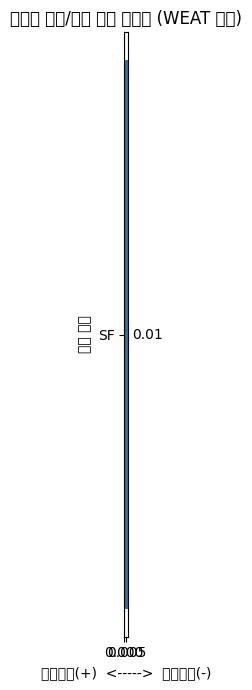

저장: /content/weat_genre_bias_bar.png


In [ ]:
bar_path = "/content/weat_genre_bias_bar.png"

scores = pd.Series(
    single_scores,
    name="WEAT"
).sort_values()

plt.figure(figsize=(11, 7))

bars = plt.barh(
    scores.index,
    scores.values
)

plt.axvline(
    0,
    color="black",
    linewidth=0.8
)

plt.xlabel(
    "예술영화(+)  <----->  일반영화(-)"
)

plt.ylabel("영화 장르")
plt.title(
    "장르별 예술/일반 영화 편향성 (WEAT 기반)"
)

# 막대 끝에 점수 표시
for bar, value in zip(bars, scores.values):
    offset = 0.01 if value >= 0 else -0.01
    ha = "left" if value >= 0 else "right"

    plt.text(
        value + offset,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}",
        va="center",
        ha=ha
    )

plt.tight_layout()

plt.savefig(
    bar_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("저장:", bar_path)

## 12. WEAT 시각화 ② 장르별 예술/일반 편향

/tmp/ipykernel_2843/1200566593.py:43: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2843/1200566593.py:43: UserWarning: Glyph 49696 (\N{HANGUL SYLLABLE SUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2843/1200566593.py:43: UserWarning: Glyph 50689 (\N{HANGUL SYLLABLE YEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2843/1200566593.py:43: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2843/1200566593.py:43: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2843/1200566593.py:43: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2843/1200566593.py:43: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) DejaVu Sans.
  plt.tight_

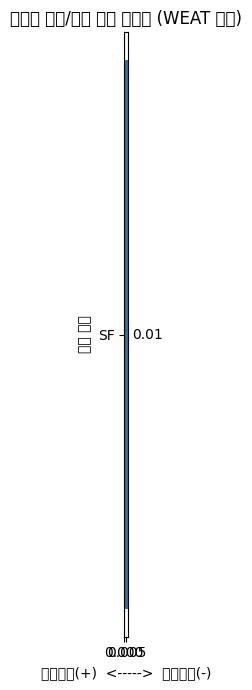

저장: /content/weat_genre_bias_bar.png


In [ ]:

bar_path = "/content/weat_genre_bias_bar.png"

scores = pd.Series(
    single_scores,
    name="WEAT"
).sort_values()

plt.figure(figsize=(11, 7))

bars = plt.barh(
    scores.index,
    scores.values
)

plt.axvline(
    0,
    color="black",
    linewidth=0.8
)

plt.xlabel(
    "예술영화(+)  <----->  일반영화(-)"
)

plt.ylabel("영화 장르")
plt.title(
    "장르별 예술/일반 영화 편향성 (WEAT 기반)"
)

# 막대 끝에 점수 표시
for bar, value in zip(bars, scores.values):
    offset = 0.01 if value >= 0 else -0.01
    ha = "left" if value >= 0 else "right"

    plt.text(
        value + offset,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}",
        va="center",
        ha=ha
    )

plt.tight_layout()

plt.savefig(
    bar_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("저장:", bar_path)


## 13. 제출용 결과 요약

In [ ]:

print("=" * 70)
print("WEAT 영화 코퍼스 분석 결과")
print("=" * 70)

print("\n[1] Word2Vec")
print("Vocabulary:", len(w2v_model.wv))
print("학습 문장 수:", len(all_sentences))

print("\n[2] Attribute")
print("예술영화:", attr_art)
print("일반영화:", attr_general)

print("\n[3] Target")
for genre, words in genre_targets.items():
    print(f"{genre}: {words}")

print("\n[4] 장르별 WEAT")
for genre, score in sorted(
    single_scores.items(),
    key=lambda x: x[1]
):
    print(f"{genre:10s}: {score:+.3f}")

print("\n[5] 생성된 시각화")
print(heatmap_path)
print(bar_path)


WEAT 영화 코퍼스 분석 결과

[1] Word2Vec
Vocabulary: 16782
학습 문장 수: 62908

[2] Attribute
예술영화: ['세상', '과연', '마을', '다시', '서로', '마음', '소녀', '우리', '인생', '아들', '다른']
일반영화: ['국제', '서울', '단편', '애니메이션', '다큐', '남편', '독립', '부산', '인디애니페스트', '부천', '대한']

[3] Target
SF: ['시작', '위해', '지구', '인류', '자신', '인간', '사람', '미래', '모든', '세계', '시간', '우주', '그녀', '존재', '로봇']
가족: []
공포: []
다큐멘터리: []
드라마: []
멜로로맨스: []
미스터리: []
범죄: []
애니메이션: []
액션: []
코미디: []
판타지: []

[4] 장르별 WEAT
SF        : +0.008
가족        : +nan
공포        : +nan
다큐멘터리     : +nan
드라마       : +nan
멜로로맨스     : +nan
미스터리      : +nan
범죄        : +nan
애니메이션     : +nan
액션        : +nan
코미디       : +nan
판타지       : +nan

[5] 생성된 시각화
/content/weat_heatmap.png
/content/weat_genre_bias_bar.png


In [ ]:

# 제출용 산출물 ZIP 생성
import shutil

output_dir = "/content/weat_submission"
os.makedirs(output_dir, exist_ok=True)

shutil.copy2(heatmap_path, output_dir)
shutil.copy2(bar_path, output_dir)

print("제출용 시각화 파일:")
print(os.listdir(output_dir))


제출용 시각화 파일:
['weat_genre_bias_bar.png', 'weat_heatmap.png']
